# Measurement x=15, y=0, z=0

### TODO


### Imports

In [38]:

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

from python_utils.utils import load_object

from python_utils.time_series_extraction import extract_timeseries_data_by_coordinates_and_column
from python_utils.time_series_extraction import find_matching_row_index_from_timeseries
from python_utils.time_series_extraction import extract_time_series_values

### General Args

In [39]:
slice_folder_path = Path("../../../data/4pi_re1000_ha1000.384.pi/SliceYZ_x0015/")
y_coord = 0  # Closest to 0.
z_coord = 0
label = 'vx'  # y, z, vx, vy, vz, jx, jy, jz, P, F=Phi
Ha = 1000

### Load Data

In [40]:
pkl_path = slice_folder_path / Path("pkl/sliceYZ_x0015_fld.pkl")

In [41]:
if 'loaded_data' not in locals():
    loaded_data = load_object(pkl_path)
    timeseries = loaded_data['timeseries']
    labels = loaded_data['labels']
print("N =", len(timeseries))
first_snapshot = timeseries[0]
n_x_y, n_v = first_snapshot.shape
n_y = n_z = np.sqrt(n_x_y)
print(f"n_y = {n_y}, n_z = {n_z}, n_v = {n_v}")
print("Labels:")
print(labels)
print("Example Data:")
print(first_snapshot[0:5, 0:3])

N = 20000
n_y = 49.0, n_z = 49.0, n_v = 10
Labels:
['y', 'z', 'vx', 'vy', 'vz', 'jx', 'jy', 'jz', 'P', 'F']
Example Data:
[[-1.        -1.         0.       ]
 [-0.9882464 -1.         0.       ]
 [-0.9697327 -1.         0.       ]
 [-0.9446967 -1.         0.       ]
 [-0.9135254 -1.         0.       ]]


### Plot $v_x$

 x = streamwise

In [42]:
column_index = labels.index(label)
v_x_center = extract_timeseries_data_by_coordinates_and_column(
    arrays=timeseries,
    column_indices=column_index,
    y_coord=y_coord,
    z_coord=z_coord,
    )

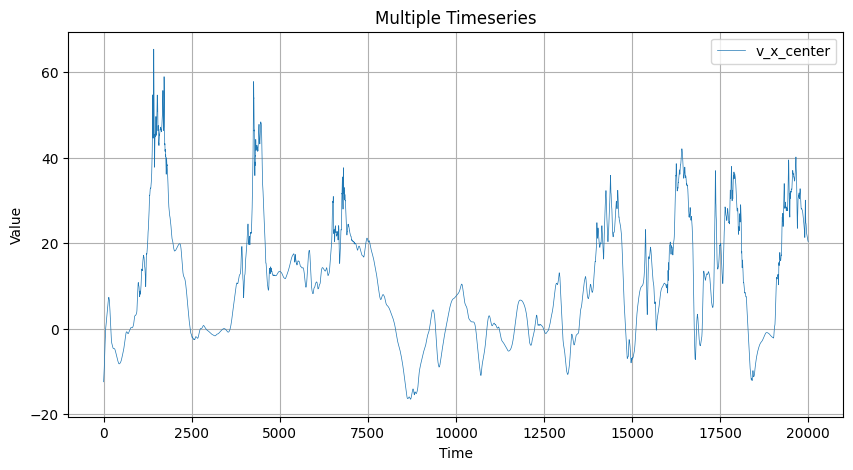

In [43]:
def plot_timeseries(
        data_list,
        *,
        labels=None,
        xlabel='Time',
        ylabel='Value',
        linewidth=1,
    ):
    # Check if data_list is a single 1D array or list
    if not isinstance(data_list, list):
        data_list = [data_list]  # Wrap in a list if it's not already
    
    # Create an array for the x-axis (time)
    time = np.arange(len(data_list[0]))  # Assuming all data series have the same length
    
    # Create a figure for plotting
    plt.figure(figsize=(10, 5))
    
    # Plot each time series in the provided list
    for i, data in enumerate(data_list):
        label = labels[i] if labels is not None else f"Timeseries {i+1}"
        plt.plot(time, data, linewidth=linewidth, label=label)
    
    plt.title('Multiple Timeseries')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid()
    plt.legend()  # Show legend to identify different timeseries
    plt.show()

plot_timeseries(
    v_x_center,
    labels=["v_x_center"],
    linewidth=0.5,
    )

## Replicate Potential Probe $v_x$ Measurements

Ohm's Law:

$\mathbf{J} = \sigma (\mathbf{E} + \mathbf{v} \times \mathbf{B})$

In vector form:

$\mathbf{J} = \begin{pmatrix} j_x \\ j_y \\ j_z \end{pmatrix} = \sigma \begin{pmatrix} E_x + (v_y B_z - v_z B_y) \\ E_y + (v_z B_x - v_x B_z) \\ E_z + (v_x B_y - v_y B_x) \end{pmatrix}$

We know that $B$ is only present in $z$-direction.

$\begin{pmatrix} j_z \\ j_y \\ j_z \end{pmatrix} = \sigma \left(\begin{pmatrix}E_x \\ E_y \\ E_z \end{pmatrix} + \begin{pmatrix}v_y B_z \\ -v_x B_z \\ 0 \end{pmatrix}\right)$

$= \sigma \left(\begin{pmatrix} \frac{\partial \varphi}{\partial x} \\ \frac{\partial \varphi}{\partial y} \\ \frac{\partial \varphi}{\partial 
z} \end{pmatrix} + \begin{pmatrix}v_y B_z \\ -v_x B_z \\ 0 \end{pmatrix}\right)$

$= \sigma \left(\begin{pmatrix} \frac{\Delta \varphi}{\Delta l_x} \\ \frac{\Delta \varphi}{\Delta l_y} \\ \frac{\Delta \varphi}{\Delta l_z} \end{pmatrix} + \begin{pmatrix}v_y B_z \\ -v_x B_z \\ 0 \end{pmatrix}\right)$

$= \sigma \left(\begin{pmatrix} \frac{\varphi_{x_2} - \varphi_{x_1}}{\Delta l_x} \\ \frac{\varphi_{y_2} - \varphi_{y_1}}{\Delta l_y} \\ \frac{\varphi_{z_2} - \varphi_{z_1}}{\Delta l_z} \end{pmatrix} + \begin{pmatrix}v_y B_z \\ -v_x B_z \\ 0 \end{pmatrix}\right)$

So, we have:

$ v_y = \frac{1}{B_z} \left( \frac{j_x}{\sigma} - \frac{\varphi_{x_2} - \varphi_{x_1}}{\Delta l_x} \right) $

$ v_x = \frac{1}{B_z} \left( \frac{\varphi_{y_2} - \varphi_{y_1}}{\Delta l_y} - \frac{j_y}{\sigma} \right) $

$ \frac{j_z}{\sigma} = \frac{\varphi_{z_2} - \varphi_{z_1}}{\Delta l_z}$

In [44]:
delta_l = 0.1  # y, z domain = [-1, 1]

##### Measurement Coordinates

In [45]:
i_center = find_matching_row_index_from_timeseries(
    timeseries,
    y_coord,
    z_coord,
    return_closest=True,
    )
print(f"Center: y = {timeseries[0][i_center][0]}, z = {timeseries[0][i_center][1]}")

y_1 = y_coord - delta_l / 2
i_y_1 = find_matching_row_index_from_timeseries(
    timeseries,
    y_1,
    z_coord,
    return_closest=True,
    )
print(f"y_1 Coordinates: y = {timeseries[0][i_y_1][0]}, z = {timeseries[0][i_y_1][1]}")
print(f"Difference to center: delta_y_1 = {timeseries[0][i_center][0] - timeseries[0][i_y_1][0]}, delta_z_1 = {timeseries[0][i_center][1] - timeseries[0][i_y_1][1]}, delta_i = {i_center - i_y_1}")

y_2 = y_coord + delta_l / 2
i_y_2 = find_matching_row_index_from_timeseries(
    timeseries,
    y_2,
    z_coord,
    return_closest=True,
    )
print(f"y_2 Coordinates: y = {timeseries[0][i_y_2][0]}, z = {timeseries[0][i_y_2][1]}")
print(f"Difference to center: delta_y_2 = {timeseries[0][i_y_2][0] - timeseries[0][i_center][0]}, delta_z_2 = {timeseries[0][i_y_2][1] - timeseries[0][i_center][1]}, delta_i = {i_y_2 - i_center}")

delta_y = timeseries[0][i_y_2][0] - timeseries[0][i_y_1][0]
delta_z = timeseries[0][i_y_2][1] - timeseries[0][i_y_1][1]
print(f"Difference between y_1 to y_2: delta_y = {delta_y}, delta_z = {delta_z}, delta_i = {i_y_2 - i_y_1}")

Center: y = 0.0, z = 0.0
y_1 Coordinates: y = -0.03460649, z = 0.0
Difference to center: delta_y_1 = 0.03460649, delta_z_1 = 0.0, delta_i = 1
y_2 Coordinates: y = 0.03460649, z = 0.0
Difference to center: delta_y_2 = 0.03460649, delta_z_2 = 0.0, delta_i = 1
Difference between y_1 to y_2: delta_y = 0.06921298, delta_z = 0.0, delta_i = 2


##### Acquire all variables

In [46]:
phi_y_1 = extract_time_series_values(
    time_series_arrays=timeseries,
    column_indices=9,
    row_index=i_y_1,
    )
phi_y_2 = extract_time_series_values(
    time_series_arrays=timeseries,
    column_indices=9,
    row_index=i_y_2,
    )
j_y_center = extract_time_series_values(
    time_series_arrays=timeseries,
    column_indices=6,
    row_index=i_center,
    )

delta_phi = phi_y_2 - phi_y_1
partial_phi = delta_phi / delta_y

##### Error Comparison

mse(gold) = 0.3977930429193704

mse(pdm) = 0.49931985994918443

mse(c_lr) = 0.4763731921394533

mse(c_lr) = 0.4747548977374998

covariance_matrix:
[[1.00005    0.99881039]
 [0.99881039 1.00005   ]]


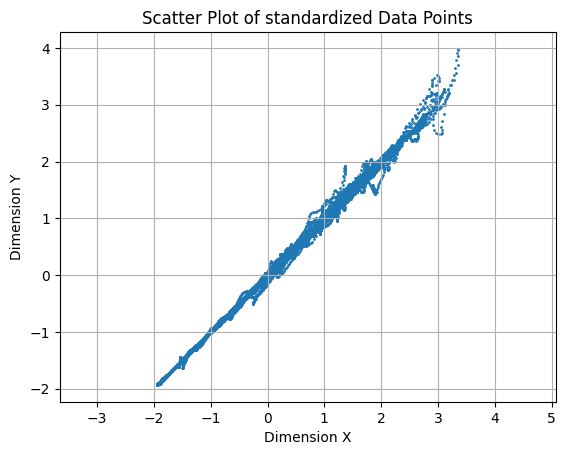

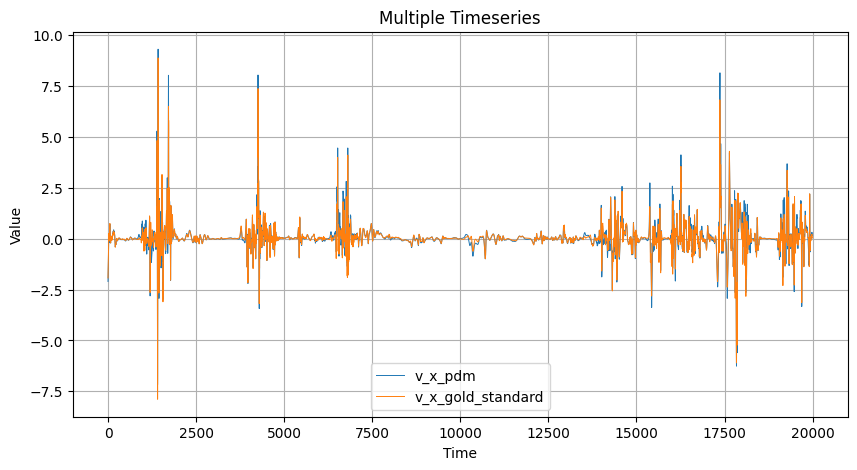

In [47]:
sigma = -1
B_z = -1

# with known j, we can not get better than this
v_x_gold_standard = (partial_phi - (j_y_center / sigma)) / B_z
print(f"mse(gold) = {mean_squared_error(v_x_center, v_x_gold_standard)}")
print()

# ignoring current j
v_x_pdm = partial_phi /B_z  # pdm = potential difference method
print(f"mse(pdm) = {mean_squared_error(v_x_center, v_x_pdm)}")
print()

# pdm with c (= LR without bias)
model = LinearRegression(fit_intercept=False)
model.fit(
    X = v_x_pdm.reshape((-1, 1)),
    y = v_x_center.reshape((-1, 1)),
    )
a = model.coef_[0, 0]
c_lr =  1 / a
v_x_c_lr = v_x_pdm / c_lr
print(f"mse(c_lr) = {mean_squared_error(v_x_center, v_x_c_lr)}")
print()

# LR
model = LinearRegression()
model.fit(
    X = v_x_pdm.reshape((-1, 1)),
    y = v_x_center.reshape((-1, 1)),
    )
v_x_lr = model.predict(v_x_pdm.reshape((-1, 1))).squeeze()
print(f"mse(c_lr) = {mean_squared_error(v_x_center, v_x_lr)}")
print()

# Covariance
v_x_pdm_norm = (v_x_pdm - np.mean(v_x_pdm)) / np.std(v_x_pdm)
v_x_center_norm = (v_x_center - np.mean(v_x_center)) / np.std(v_x_center)
_data = np.vstack((v_x_pdm_norm, v_x_center_norm))
covariance_matrix = np.cov(_data)
print("covariance_matrix:")
print(covariance_matrix)
# Plotting the data points
plt.scatter(
    v_x_pdm_norm,
    v_x_center_norm,
    s=1,
    )
plt.title('Scatter Plot of standardized Data Points')
plt.xlabel('Dimension X')
plt.ylabel('Dimension Y')
plt.grid(True)
plt.axis('equal')  # Equal scaling for both axes
plt.show()

plot_timeseries(
    [
        # v_x_center - v_x_c_lr,
        # v_x_center - v_x_lr,
        v_x_center - v_x_pdm,
        v_x_center - v_x_gold_standard,
        ],
    labels=[
        # "v_x_c_lr",
        # "v_x_lr",
        "v_x_pdm",
        "v_x_gold_standard",
        ],
    linewidth=0.7,
    )

##### Calculate $v_x$ Potential Probe Estimation

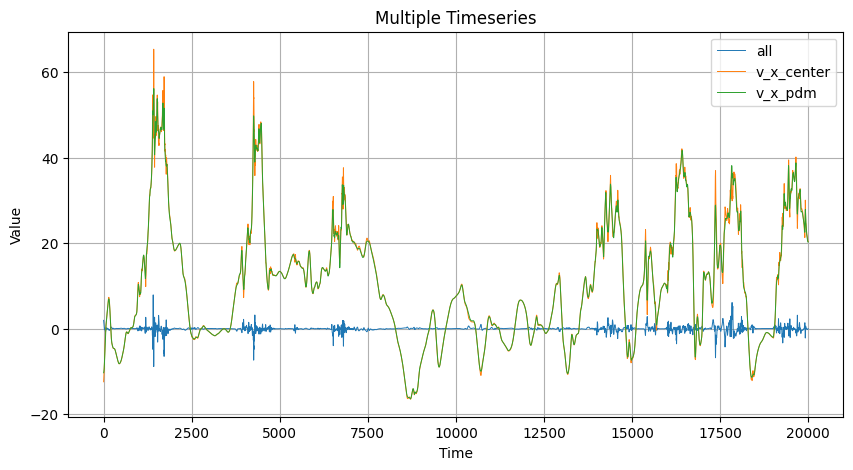

In [30]:
B_z = -1
sigma = -1
all = (partial_phi - j_y_center / sigma) / B_z
v_x_pdm = partial_phi / B_z  # pdm = potential difference method
plot_timeseries(
    [
        all - v_x_center,
        v_x_center,
        v_x_pdm,
        ],
    labels=[
        "all",
        "v_x_center",
        "v_x_pdm",
        ],
    linewidth=0.7,
    )

##### Calculate $B_z$

mean(B_z) = -0.9211511758356467
median(B_z) = -0.996040502595791


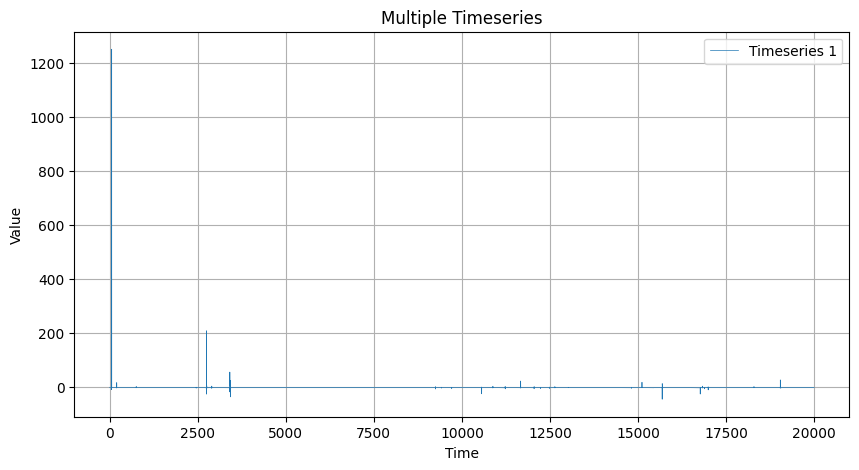

In [31]:
B_z = np.divide(
    partial_phi - j_y_center / sigma,
    # partial_phi,
    v_x_center,
    )

print(f"mean(B_z) = {np.mean(B_z)}")
print(f"median(B_z) = {np.median(B_z)}")
plot_timeseries(
    B_z,
    linewidth=0.5,
    )

##### Calculate Sigma

mean(sigma) = -1.0000000000000233
median(sigma) = -1.0


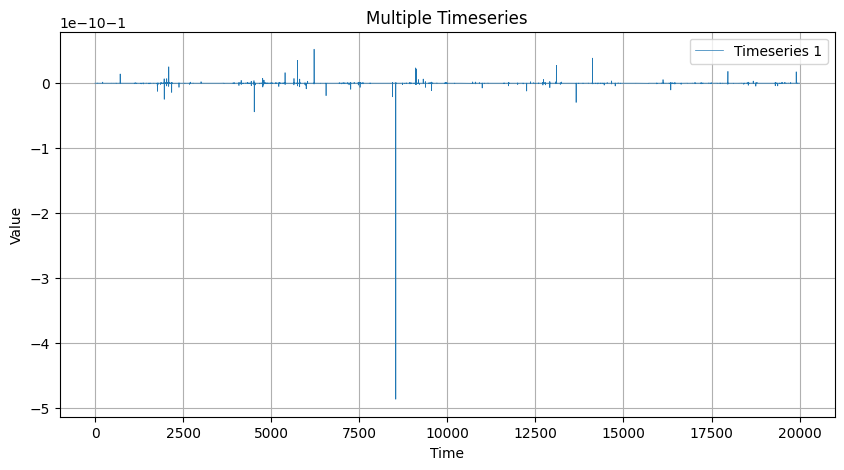

In [32]:
sigma = np.divide(
    j_y_center,
    partial_phi - v_x_center * B_z,
    )

print(f"mean(sigma) = {np.mean(sigma)}")
print(f"median(sigma) = {np.median(sigma)}")
plot_timeseries(
    sigma,
    linewidth=0.5,
    )

### Ohm's Law in z-coord

In [33]:
delta_l = 0.1  # y, z domain = [-1, 1]

##### Measurement Coordinates

In [34]:
i_center = find_matching_row_index_from_timeseries(
    timeseries,
    y_coord,
    z_coord,
    return_closest=True,
    )
print(f"Center: y = {timeseries[0][i_center][0]}, z = {timeseries[0][i_center][1]}")

z_1 = z_coord - delta_l / 2
i_z_1 = find_matching_row_index_from_timeseries(
    timeseries,
    y_coord,
    z_1,
    return_closest=True,
    )
print(f"z_1 Coordinates: y = {timeseries[0][i_z_1][0]}, z = {timeseries[0][i_z_1][1]}")
print(f"Difference to center: delta_y_1 = {timeseries[0][i_center][0] - timeseries[0][i_z_1][0]}, delta_z_1 = {timeseries[0][i_center][1] - timeseries[0][i_z_1][1]}, delta_i = {i_center - i_z_1}")

z_2 = z_coord + delta_l / 2
i_z_2 = find_matching_row_index_from_timeseries(
    timeseries,
    y_coord,
    z_2,
    return_closest=True,
    )
print(f"z_2 Coordinates: y = {timeseries[0][i_z_2][0]}, z = {timeseries[0][i_z_2][1]}")
print(f"Difference to center: delta_y_2 = {timeseries[0][i_z_2][0] - timeseries[0][i_center][0]}, delta_z_2 = {timeseries[0][i_z_2][1] - timeseries[0][i_center][1]}, delta_i = {i_z_2 - i_center}")

delta_y = timeseries[0][i_z_2][0] - timeseries[0][i_z_1][0]
delta_z = timeseries[0][i_z_2][1] - timeseries[0][i_z_1][1]
print(f"Difference between z_1 to z_2: delta_y = {delta_y}, delta_z = {delta_z}, delta_i = {i_z_2 - i_z_1}")

Center: y = 0.0, z = 0.0
z_1 Coordinates: y = 0.0, z = -0.03460649
Difference to center: delta_y_1 = 0.0, delta_z_1 = 0.03460649, delta_i = 49
z_2 Coordinates: y = 0.0, z = 0.03460649
Difference to center: delta_y_2 = 0.0, delta_z_2 = 0.03460649, delta_i = 49
Difference between z_1 to z_2: delta_y = 0.0, delta_z = 0.06921298, delta_i = 98


##### Acquire all variables

In [35]:
phi_z_1 = extract_time_series_values(
    time_series_arrays=timeseries,
    column_indices=9,
    row_index=i_z_1,
    )
phi_z_2 = extract_time_series_values(
    time_series_arrays=timeseries,
    column_indices=9,
    row_index=i_z_2,
    )
j_z_center = extract_time_series_values(
    time_series_arrays=timeseries,
    column_indices=7,
    row_index=i_center,
    )

delta_phi = phi_z_2 - phi_z_1
partial_phi = delta_phi / delta_z

##### Plot

mean(root) = 0.0009727365140331056
median(root) = -9.819085367733169e-07


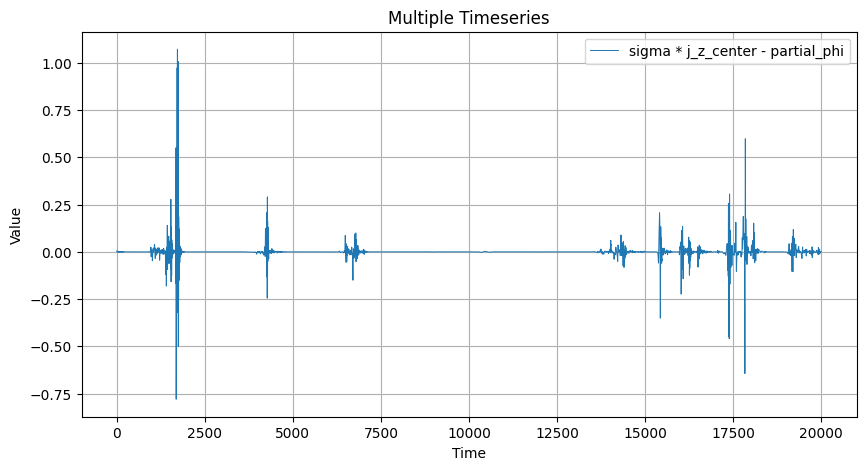

In [36]:
sigma = -1
root = sigma * j_z_center - partial_phi
print(f"mean(root) = {np.mean(root)}")
print(f"median(root) = {np.median(root)}")
plot_timeseries(
    [
        root,
        ],
    labels=[
        "sigma * j_z_center - partial_phi",
        ],
    linewidth=0.7,
    )

##### Calculate Sigma

mean(sigma) = 8819.487457626743
median(sigma) = -1.0008070122210997


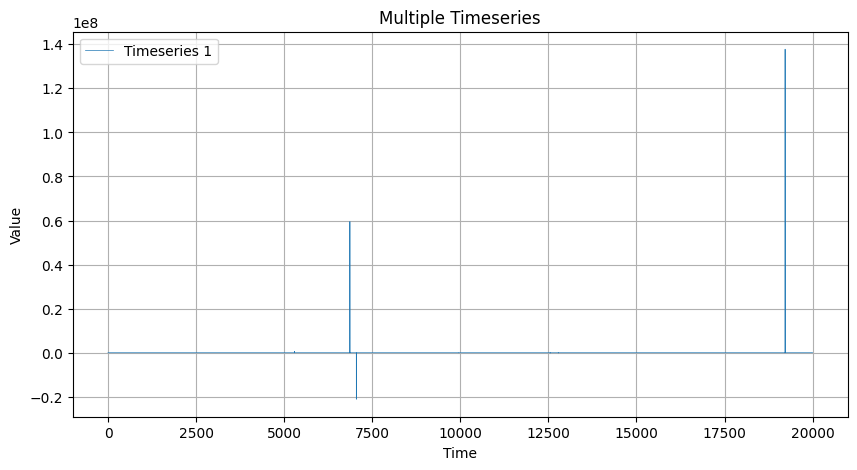

In [37]:
sigma = np.divide(
    j_z_center,
    partial_phi + 1e-10,  # We have 0s within partial_phi.
    )

print(f"mean(sigma) = {np.mean(sigma)}")
print(f"median(sigma) = {np.median(sigma)}")
plot_timeseries(
    sigma,
    linewidth=0.5,
    )